## Packages, Functions, and Initial Data Pre-porcession

## Functions

In [2]:
# This is our default function, the one we use to prep the data for the encoder that takes us from spectra to ChemNet encodings 
def create_dataset_tensors(spectra_dataset, embedding_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors from the provided spectra dataset and embedding DataFrame.

    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels. Assumes specific 
        columns for processing based on the `carl` flag.

    embedding_df : pd.DataFrame
        DataFrame containing embeddings for chemicals, with 'Embedding Floats' 
        column corresponding to ChemNet embeddings.

    device : torch.device
        The device (CPU or GPU) on which to store the tensors.

    carl : bool, optional
        If True, processes the dataset assuming it has a different structure 
        (specifically without an 'Unnamed: 0' column). Default is False.

    Returns:
    -------
    tuple
        A tuple containing:
        - embeddings_tensor (torch.Tensor): Tensor of true embeddings for the chemicals.
        - spectra_tensor (torch.Tensor): Tensor of spectral data.
        - chem_encodings_tensor (torch.Tensor): Tensor of chemical name encodings.
        - spectra_indices_tensor (torch.Tensor): Tensor of indices corresponding to the spectra.
    """
    spectra = spectra_dataset.iloc[:,1:-3]

    # create tensors of spectra, true embeddings, and chemical name encodings for train and val
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_tensor = torch.Tensor(spectra.values).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return embeddings_tensor, spectra_tensor, spectra_indices_tensor #, chem_encodings_tensor

In [3]:
def apply_threshold_filter(df, threshold):
    """
    Applies a threshold filter to spectral data, setting values below threshold to zero.
    
    Parameters:
    df: DataFrame with first column as SMILES, last column as index_id, rest as spectral intensity columns
    threshold: Float, minimum value to keep (values below this become 0)
    
    Returns:
    DataFrame with filtered spectral data (values below threshold set to 0)
    """
    
    # Create a copy to avoid modifying the original
    filtered_df = df.copy()
    
    # Get spectral columns (all except first and last column)
    spectral_cols = filtered_df.columns[1:-1]
    
    # Ensure spectral data is numeric
    # filtered_df[spectral_cols] = filtered_df[spectral_cols].apply(pd.to_numeric, errors='coerce')
    
    # Apply threshold using numpy where - more explicit control
    spectral_data = filtered_df[spectral_cols].values
    spectral_data = np.where(spectral_data >= threshold, spectral_data, 0)
    filtered_df[spectral_cols] = spectral_data
    
    # index_id column is preserved unchanged
    return filtered_df

In [4]:
def bin_spectra_by_mz_range(df, bin_size):
    """
    Bins spectra data by grouping m/z columns into ranges of specified size.
    
    Parameters:
    df: DataFrame with first column as SMILES, last column as index_id, rest as m/z columns (float names)
    bin_size: Float, the size of each bin (e.g., 10 means bins of 0-10, 10-20, etc.)
    
    Returns:
    DataFrame with SMILES column, binned m/z columns named by bin midpoints, and index_id column
    """
    smiles_col = df.columns[0]
    index_col = df.columns[-1]  # Preserve the last column (index_id)
    mz_cols = df.columns[1:-1]  # Exclude first and last columns
    
    # Create bins and assign each m/z to a bin
    bin_assignments = {}
    for mz in mz_cols:
        bin_start = (mz // bin_size) * bin_size
        bin_end = bin_start + bin_size
        bin_midpoint = bin_start + (bin_size / 2)
        
        # Round to avoid floating point precision issues
        bin_midpoint = round(bin_midpoint, 3)  
        
        if bin_midpoint not in bin_assignments:
            bin_assignments[bin_midpoint] = []
        bin_assignments[bin_midpoint].append(mz)
    
    # Create new DataFrame with binned data
    result_df = pd.DataFrame()
    result_df[smiles_col] = df[smiles_col]
    
    # Sum intensities for each bin
    for bin_midpoint in sorted(bin_assignments.keys()):
        cols_in_bin = bin_assignments[bin_midpoint]
        result_df[bin_midpoint] = df[cols_in_bin].sum(axis=1)
    
    # Preserve index_id column
    result_df[index_col] = df[index_col]
    
    return result_df

In [5]:
def fill_missing_bins(df, bin_size):
    """
    Fills in missing bin columns in a binned DataFrame.
    
    Parameters:
    df: DataFrame with first column as SMILES, last column as index_id, rest as binned m/z columns (float names)
    bin_size: Float, the original bin size used for binning
    
    Returns:
    DataFrame with all missing bin midpoints filled in with zeros
    """
    smiles_col = df.columns[0]
    index_col = df.columns[-1]  # Preserve the last column (index_id)
    existing_bins = sorted([col for col in df.columns[1:-1] if isinstance(col, (int, float))])
    
    if not existing_bins:
        return df
    
    # Calculate the step size 
    step_size = bin_size
    
    # Find the range of bins to fill
    min_bin = existing_bins[0]
    max_bin = existing_bins[-1]
    
    # Generate all possible bin midpoints from first non-zero step to max_bin
    all_bins = []
    current_bin = step_size / 2  # Start from first non-zero bin (don't include 0)
    while current_bin <= max_bin:
        all_bins.append(current_bin)
        current_bin += step_size
    
    # Find missing bins
    missing_bins = set(all_bins) - set(existing_bins)
    
    # Add missing bins with zeros
    result_df = df.copy()
    for bin_midpoint in missing_bins:
        result_df[bin_midpoint] = 0.0
    
    # Reorder columns: SMILES column first, then sorted bin columns, then index_id column
    bin_cols = sorted([col for col in result_df.columns[1:-1] if isinstance(col, (int, float))])
    ordered_cols = [smiles_col] + bin_cols + [index_col]
    result_df = result_df[ordered_cols]
    
    return result_df

In [6]:
# Add the 'Response' and 'log_response' columns 
def add_response_and_log_response(spectra_df, original_df, smiles_col='SMILES_spectra'):
    """
    Adds 'Response' and 'log_response' columns to spectra_df by mapping from original_df using the SMILES column.
    """
    smiles_to_response = original_df.drop_duplicates(subset=smiles_col).set_index(smiles_col)['Response']
    spectra_df['Response'] = spectra_df[smiles_col].map(smiles_to_response)
    spectra_df['log_response'] = np.log(spectra_df['Response'])
    return spectra_df

In [7]:
# Spectrum string to dataframe function
def spectrum_string_to_dataframe(df, spectrum_col, smiles_col):
    """
    Converts a DataFrame with a spectrum column (string of 'x:y' pairs) into a matrix
    where columns are unique x values, rows are spectra (even for duplicate SMILES), and values are y (intensity).
    The index will match the original DataFrame.
    """
    # Collect all unique x values (m/z)
    x_values_set = set()
    spectra_list = []
    for idx, row in df.iterrows():
        spectrum = row[spectrum_col]
        pairs = spectrum.split()
        xys = []
        for pair in pairs:
            try:
                x, y = pair.split(":") # Split into x and y
                #x = float(x.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                #y = float(y.replace("'", "").replace('"', '')) # Remove quotes and convert to float (done in processing)
                xys.append((x, y))
                x_values_set.add(x)
            except Exception:
                continue
        spectra_list.append((row[smiles_col], dict(xys)))
    x_values = sorted(x_values_set) # Sort the x values to maintain order
    
    # Build the matrix
    matrix = []
    smiles_list = []
    for smiles, xy_dict in spectra_list:
        row = [xy_dict.get(x, 0.0) for x in x_values]
        matrix.append(row)
        smiles_list.append(smiles)
    df_matrix = pd.DataFrame(matrix, columns=[x for x in x_values]) # columns=[f"mz_{x}" for x in x_values]) to make stings
    df_matrix.insert(0, smiles_col, smiles_list)
    df_matrix.index = df.index  # preserve original row order/index
    return df_matrix

## Import

In [8]:
# Package imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import seaborn as sns

# from fcd_torch import FCD
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.decomposition import PCA

from fcd_torch import FCD
import rdkit

import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import functions_enc as f

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor



## Initial Pre-processing

In [9]:
# The 5/30 dataset with rat based toxicity data and groups
df3 = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/MIT_LL_data3.csv")
print(df3.shape)
df3.head()

# Uniformity of ionization model labels
print(df3["Ionization_Mode"].unique())
df3["Ionization_Mode"] = df3["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df3["Ionization_Mode"].unique())

# Remove the N/A values in Ionization_Mode
df3 = df3[df3["Ionization_Mode"] != "'NaN'"]
print(df3["Ionization_Mode"].unique())

# Removing the '' from the SMILES
# Remove single quotes from all string columns in df3
df3 = df3.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)
#df3["SMILES_spectra"] = df3["SMILES_spectra"].str.replace("'", "")

# This will give us the subsets with all of the relevant information
df3_QQpos = df3[df3['Group'] == 'Q-Orbitrap-positive'] # 1307

# # At the moment we only care about Q-Orbitrap-positive data and not the other instrument and ionization mode groups
# df3_QQneg = df3[df3['Group'] == 'Q-Orbitrap-negative'] # 756
# df3_QTOFpos = df3[df3['Group'] == 'Q-TOF-positive'] # 736  
# df3_LTQOpos = df3[df3['Group'] == 'LTQ-Orbitrap-positive'] # 481 


(4001, 16)
["'positive'" "'negative'" "'Positive'" "'NaN'"]
["'positive'" "'negative'" "'NaN'"]
["'positive'" "'negative'"]


In [10]:
df3_QQpos_spectra = spectrum_string_to_dataframe(df3_QQpos, "Spectrum", "SMILES_spectra")

# Data processing using the function
cols = df3_QQpos_spectra.columns.tolist()
# Keep the first column as is, convert the rest to float
new_cols = [cols[0]] + [float(c) for c in cols[1:]]
df3_QQpos_spectra.columns = new_cols
df3_QQpos_spectra.iloc[:, 1:] = df3_QQpos_spectra.iloc[:, 1:].apply(pd.to_numeric, errors='coerce')
all_float = all(isinstance(c, float) for c in df3_QQpos_spectra.columns[1:])
print("All columns are float:", all_float)


spectra = df3_QQpos_spectra.iloc[:, 1:]

# Check if every element is a float
all_float_elements = spectra.applymap(lambda x: isinstance(x, float)).all().all()
print("All elements are float:", all_float_elements)

# Sort columns by their names 
first_col = df3_QQpos_spectra.columns[0]
sorted_cols = [first_col] + sorted(df3_QQpos_spectra.columns[1:])
df3_QQpos_spectra = df3_QQpos_spectra[sorted_cols]

# Add unique index_id column for outlier tracking
df3_QQpos_spectra['index_id'] = range(len(df3_QQpos_spectra))

print(f"Data processing complete. Shape: {df3_QQpos_spectra.shape}")
print(f"Added index_id column with values from 0 to {len(df3_QQpos_spectra)-1}")
print(f"Columns: SMILES + {len(df3_QQpos_spectra.columns)-2} spectral features + index_id")


All columns are float: True
All elements are float: True
Data processing complete. Shape: (1307, 39664)
Added index_id column with values from 0 to 1306
Columns: SMILES + 39662 spectral features + index_id


In [11]:
df3_QQpos_spectra.head()

,SMILES_spectra,49.5027114573,49.5027551965,49.5027553798,49.5027618179,49.5027656578,49.5027657864,49.5027658251,49.5027690235,49.5027714062,...,545.479554401,545.47960817,545.479619545,545.479638251,555.3646,555.3654,603.3863,661.428,679.4382,index_id
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4


# Binning Loop

In [12]:
# # Storage of the original data
# df3_QQpos_spectra_original = df3_QQpos_spectra.copy()

# # Define bin sizes and threshold values
# bin_sizes = [0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
# thresholds = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]

# print(f"Generating {len(bin_sizes)} × {len(thresholds)} = {len(bin_sizes) * len(thresholds)} dataset combinations...")

# # Suppress warnings during dataset generation
# import warnings

# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
    
#     # Generate all combinations of bin sizes and thresholds
#     for bin_size in bin_sizes:
#         for threshold in thresholds:
#             # Create variable names
#             bin_str = str(bin_size).replace('.', '_') # Replace dots with underscores to avoid duplicate variable names
#             thresh_str = str(threshold).replace('.', '_')
#             var_name = f"bin{bin_str}_thresh{thresh_str}_df3_QQpos_spectra" # Maintain some variable name uniformity
            
#             print(f"Processing bin_size={bin_size}, threshold={threshold} -> {var_name}")
            
#             # Copy the origninal data to prevent functional repeating issues
#             current_data = df3_QQpos_spectra_original.copy()
            
#             # Threshold filter 
#             filtered_data = apply_threshold_filter(current_data, threshold)
            
#             # Binning
#             binned_data = bin_spectra_by_mz_range(filtered_data, bin_size)
            
#             # Fill missing bins
#             filled_data = fill_missing_bins(binned_data, bin_size)
            
#             # Add response and log response values (Only log response is strictly needed)
#             final_data = add_response_and_log_response(filled_data, df3_QQpos)
            
#             # Ensure index_id is preserved from original data
#             final_data['index_id'] = df3_QQpos_spectra['index_id'].iloc[:len(final_data)].values
            
#             # Store in globals() for dynamic variable creation
#             globals()[var_name] = final_data
            
#             # Save to file
#             save_path = f"/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/{var_name}.pkl"
#             final_data.to_pickle(save_path)
#             print(f"Saved {var_name} to {save_path}")

# print(f"\nCompleted! Generated {len(bin_sizes) * len(thresholds)} datasets.")

In [13]:
# # Create the missing threhold 0 datasets
# print("Creating binned-only datasets (thresh0)...")

# bin_sizes = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore")
    
#     for bin_size in bin_sizes:
#         # Create variable name for thresh0 (no threshold)
#         bin_str = str(bin_size).replace('.', '_')
#         var_name = f"bin{bin_str}_thresh_zero_df3_QQpos_spectra"
    
#         print(f"Creating {var_name}...")
    
#         # Start with original data (no threshold filtering)
#         current_data = df3_QQpos_spectra_original.copy()
    
#         # Binning only
#         binned_data = bin_spectra_by_mz_range(current_data, bin_size)
    
#         # Fill missing bins
#         filled_data = fill_missing_bins(binned_data, bin_size)
    
#         # Add response and log response values
#         final_data = add_response_and_log_response(filled_data, df3_QQpos)
        
#         # Ensure index_id is preserved from original data
#         final_data['index_id'] = df3_QQpos_spectra['index_id'].iloc[:len(final_data)].values
        
#         # Store in globals()
#         globals()[var_name] = final_data
        
#         # Save to file
#         save_path = f"/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/{var_name}.pkl"
#         final_data.to_pickle(save_path)
#         print(f"Saved {var_name} to {save_path}")

# print(f"Created {len(bin_sizes)} thresh0 datasets!")

# Random Forest on Spectra

In [14]:
import os
import pickle

# Load all datasets from the grid_search_dataframes folder
grid_search_folder = "/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

# Get all .pkl files in the folder
pkl_files = [f for f in os.listdir(grid_search_folder) if f.endswith('.pkl')]
dataset_names = [f.replace('.pkl', '') for f in pkl_files]

print(f"Found {len(dataset_names)} datasets to process")
print(f"Expected: 180 datasets")

# Load datasets into globals for compatibility with existing code
for dataset_name in dataset_names:
    file_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    globals()[dataset_name] = pd.read_pickle(file_path)

# Verify we have the right count
thresh0_datasets = [name for name in dataset_names if 'thresh_zero' in name]
thresholded_datasets = [name for name in dataset_names if 'thresh_zero' not in name]

print(f"  - Datasets with thresh0 (no threshold): {len(thresh0_datasets)}")
print(f"  - Datasets with thresholds applied: {len(thresholded_datasets)}")

# Initialize storage for results
results_r2 = []
results_percent_error = []

# Loop through the datasets
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"Processing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Fetch the dataset from globals()
        df = globals()[dataset_name]
        
        # Prepare features and target
        feature_cols = [col for col in df.columns if col not in ['SMILES_spectra', 'Response', 'log_response', 'index_id']]
        X = df[feature_cols]
        y = df['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
        
        # Train Random Forest
        rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf.fit(X_train, y_train)
        
        # Make predictions
        y_train_pred = rf.predict(X_train)
        y_test_pred = rf.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue

# Convert results to DataFrames
df_r2_results = pd.DataFrame(results_r2)
df_percent_error_results = pd.DataFrame(results_percent_error)

print(f"\nCompleted! Processed {len(results_r2)} datasets successfully.")
print(f"Results stored in: df_r2_results, df_percent_error_results")

# Display summary statistics
print("\n=== SUMMARY STATISTICS ===")
print("Test R² Statistics:")
print(df_r2_results['Test_R2'].describe())

print("\nTest Median Percent Error Statistics:")
print(df_percent_error_results['Test_Median_Percent_Error'].describe())

print("\nTest Mean Percent Error Statistics:")
print(df_percent_error_results['Test_Mean_Percent_Error'].describe())

# Show top 10 performing datasets by Test R²
print("\n=== TOP 10 DATASETS BY TEST R² ===")
top_r2 = df_r2_results.nlargest(10, 'Test_R2')[['Dataset', 'Test_R2', 'Features']]
print(top_r2.to_string(index=False))

# Show comparison between thresh0 (no threshold) and thresholded datasets
print("\n=== THRESH0 vs THRESHOLDED COMPARISON ===")
thresh0_results = df_r2_results[df_r2_results['Dataset'].str.contains('thresh_zero')]
thresholded_results = df_r2_results[~df_r2_results['Dataset'].str.contains('thresh_zero')]

if len(thresh0_results) > 0:
    print(f"Thresh0 datasets (no threshold) - Mean Test R²: {thresh0_results['Test_R2'].mean():.4f}")
    print(f"Best thresh0 dataset: {thresh0_results.loc[thresh0_results['Test_R2'].idxmax(), 'Dataset']} (R² = {thresh0_results['Test_R2'].max():.4f})")

if len(thresholded_results) > 0:
    print(f"Thresholded datasets - Mean Test R²: {thresholded_results['Test_R2'].mean():.4f}")
    print(f"Best thresholded dataset: {thresholded_results.loc[thresholded_results['Test_R2'].idxmax(), 'Dataset']} (R² = {thresholded_results['Test_R2'].max():.4f})")

Found 180 datasets to process
Expected: 180 datasets
  - Datasets with thresh0 (no threshold): 12
  - Datasets with thresholds applied: 168
Processing 1/180: bin0_01_thresh0_001_df3_QQpos_spectra
Completed: Test R² = 0.7475, Test Median % Error = 32.4%
Processing 2/180: bin0_01_thresh0_005_df3_QQpos_spectra
Completed: Test R² = 0.7351, Test Median % Error = 31.7%
Processing 3/180: bin0_01_thresh0_01_df3_QQpos_spectra
Completed: Test R² = 0.7433, Test Median % Error = 32.0%
Processing 4/180: bin0_01_thresh0_05_df3_QQpos_spectra
Completed: Test R² = 0.7396, Test Median % Error = 32.9%
Processing 5/180: bin0_01_thresh0_1_df3_QQpos_spectra
Completed: Test R² = 0.7331, Test Median % Error = 33.8%
Processing 6/180: bin0_01_thresh0_5_df3_QQpos_spectra
Completed: Test R² = 0.7280, Test Median % Error = 30.2%
Processing 7/180: bin0_01_thresh100_df3_QQpos_spectra
Completed: Test R² = 0.1291, Test Median % Error = 49.5%
Processing 8/180: bin0_01_thresh10_df3_QQpos_spectra
Completed: Test R² = 0.5

## Spectra Heatmap

In [16]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df3_QQpos_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_mse_results, df_r2_results, df_rmse_results, df_abs_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_mse_results = df_mse_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_rmse_results = df_rmse_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_abs_percent_error_results = df_abs_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
mse_pivot = df_mse_results.pivot(index='BinSize', columns='Threshold', values='Test_MSE')
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
rmse_pivot = df_rmse_results.pivot(index='BinSize', columns='Threshold', values='Test_RMSE')
abs_percent_error_pivot = df_abs_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Abs_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100] # [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000] # [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
mse_pivot = mse_pivot.reindex(columns=thresholds_subset, index=bins_subset)
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
rmse_pivot = rmse_pivot.reindex(columns=thresholds_subset, index=bins_subset)
abs_percent_error_pivot = abs_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Create the heatmaps
fig, axes = plt.subplots(1, 4, figsize=(26, 6))

# MSE Heatmap
sns.heatmap(mse_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Reds',
            ax=axes[0],
            cbar_kws={'label': 'Test MSE'})
axes[0].set_title('MSE by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Threshold Value', fontsize=12)
axes[0].set_ylabel('Bin Size', fontsize=12)
axes[0].invert_yaxis()

# R² Heatmap
sns.heatmap(r2_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            ax=axes[1],
            cbar_kws={'label': 'Test R²'})
axes[1].set_title('R² by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Threshold Value', fontsize=12)
axes[1].set_ylabel('Bin Size', fontsize=12)
axes[1].invert_yaxis()

# RMSE Heatmap
sns.heatmap(rmse_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Oranges',
            ax=axes[2],
            cbar_kws={'label': 'Test RMSE'})
axes[2].set_title('RMSE by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Threshold Value', fontsize=12)
axes[2].set_ylabel('Bin Size', fontsize=12)
axes[2].invert_yaxis()

# Abs Percent Error Heatmap
sns.heatmap(abs_percent_error_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Purples',
            ax=axes[3],
            cbar_kws={'label': 'Test Abs % Error'})
axes[3].set_title('Median Absolute Percent Error', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Threshold Value', fontsize=12)
axes[3].set_ylabel('Bin Size', fontsize=12)
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

min_val = 10.0
max_val = 90.0
# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8)):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.4f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin = min_val,
                vmax = max_val,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Spectra:{metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if metric_name == 'R²':
        best_val = pivot_data.max().max()
        best_pos = np.where(pivot_data == best_val)
        if len(best_pos[0]) > 0:
            plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                    transform=plt.gca().transAxes, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        best_pos = np.where(pivot_data == best_val)
        if len(best_pos[0]) > 0:
            plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.4f}', 
                    transform=plt.gca().transAxes, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

# # Create detailed individual heatmaps
# print("Creating detailed heatmaps...")

# create_detailed_heatmap(mse_pivot, 'MSE', 'RdYlBu_r')  
# create_detailed_heatmap(r2_pivot, 'R²', 'RdYlBu')     
# create_detailed_heatmap(rmse_pivot, 'RMSE', 'RdYlBu_r') 
create_detailed_heatmap_spec(abs_percent_error_pivot, ' Median Absolute Percent Error', 'RdYlBu_r') # For mean replace with 'Mean Absolute Percent Error'
# create_detailed_heatmap(abs_percent_error_pivot, 'Mean Absolute Percent Error', 'RdYlBu_r')

NameError: name 'df_mse_results' is not defined

Checking for duplicates in results...
Original df_r2_results shape: (180, 7)
After removing duplicates: (180, 7)


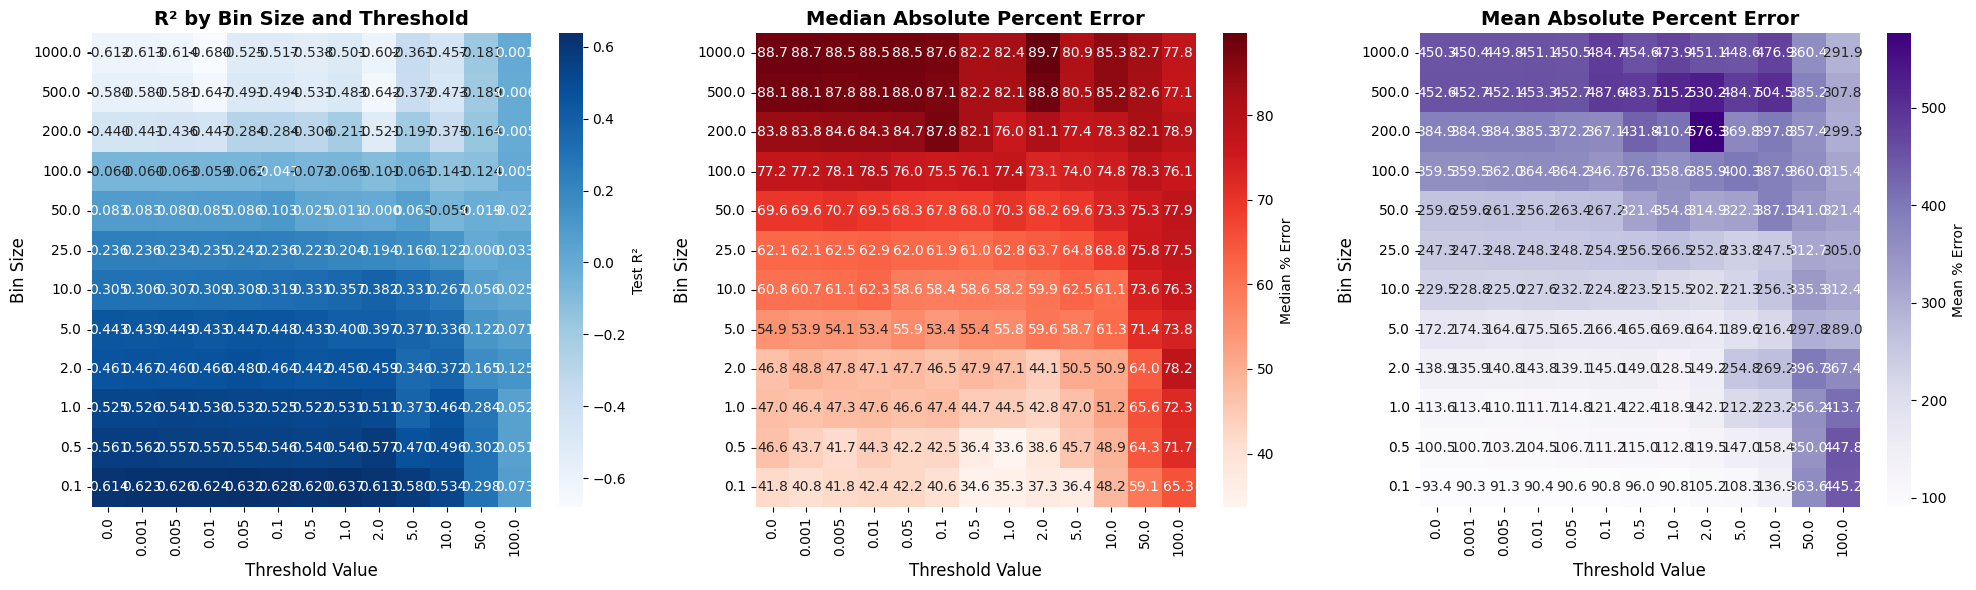

Creating detailed heatmaps...


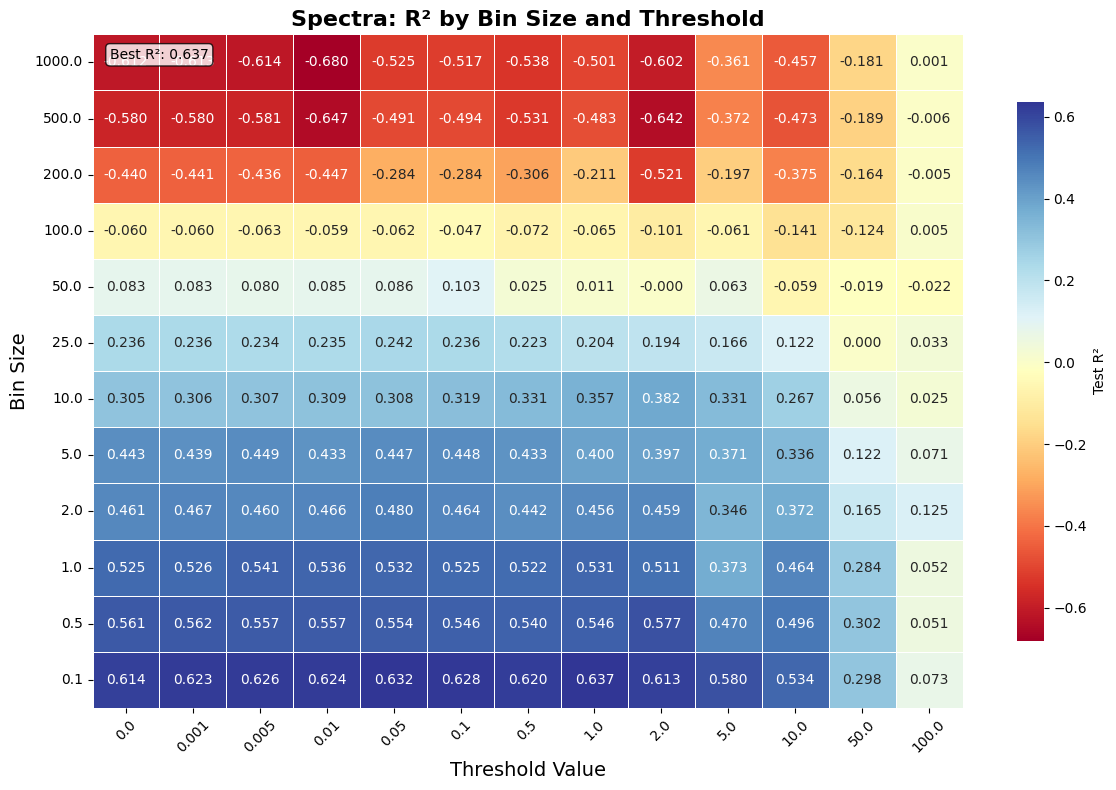

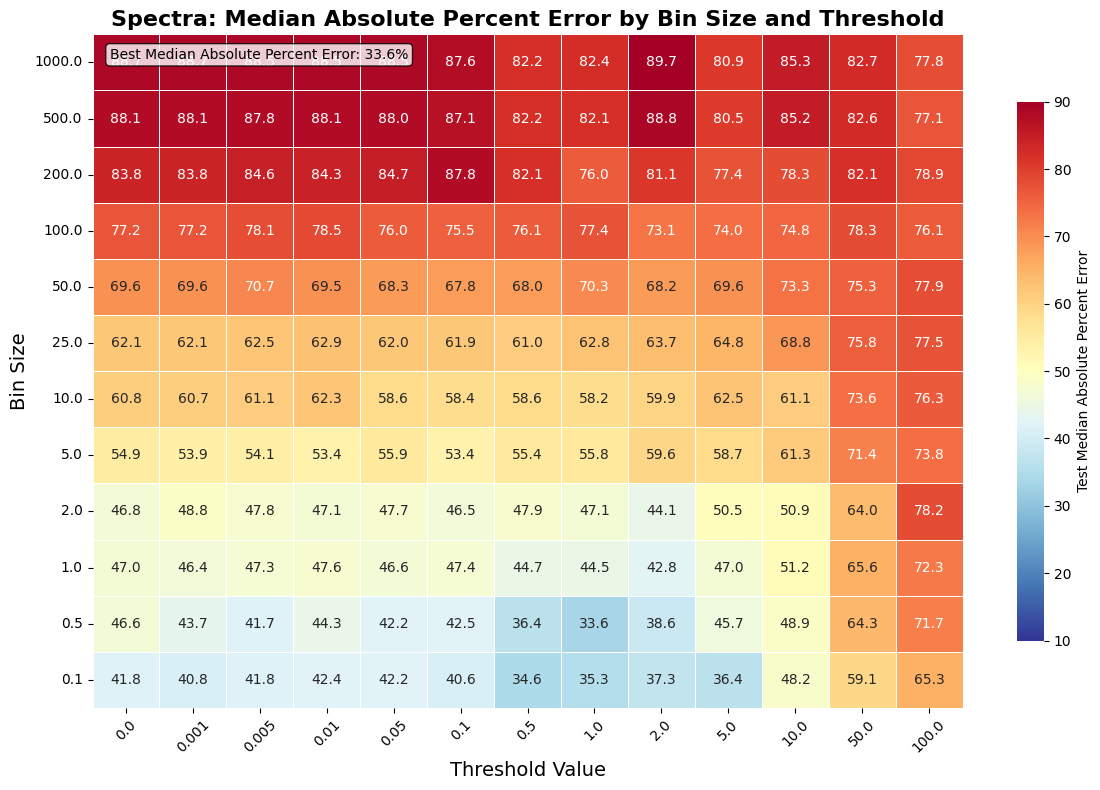

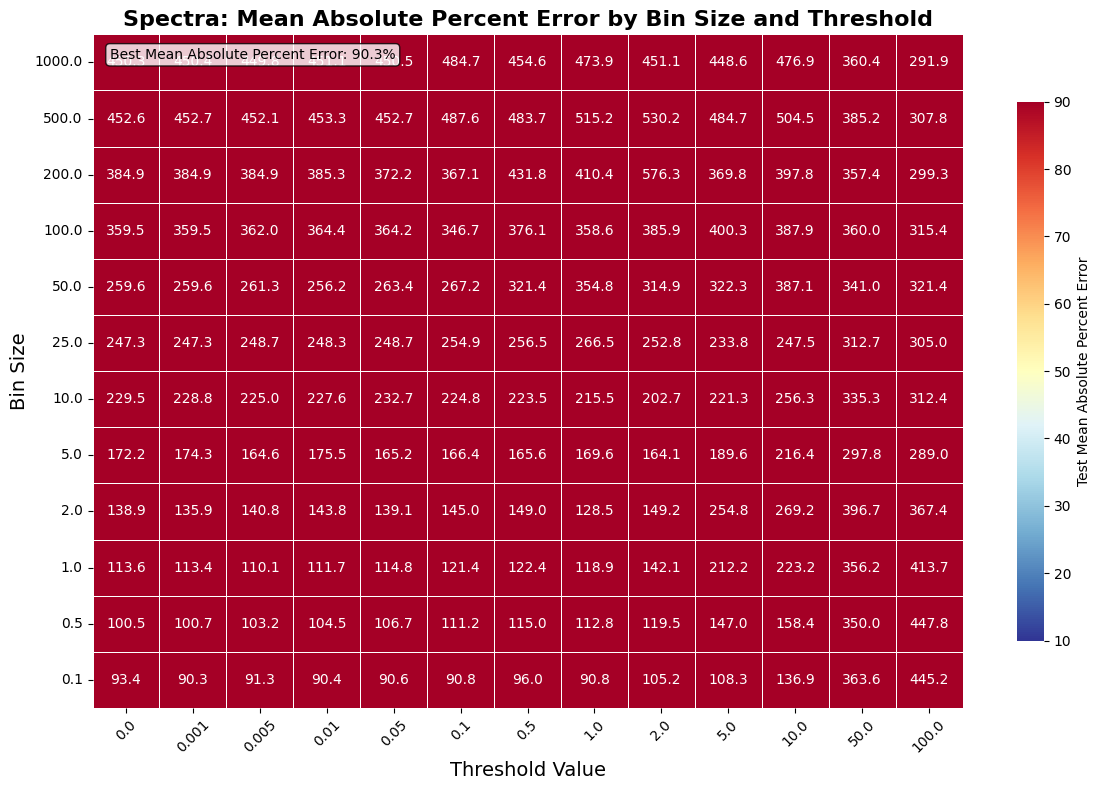

In [ ]:
# Create the actual heatmaps for visualization
# First, let's extract bin size and threshold from the dataset names and add to results
def parse_dataset_name(dataset_name):
    """Extract bin size and threshold from dataset name"""
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in dataset_name:
        # Extract bin size
        bin_part = dataset_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = dataset_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df3_QQpos_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to results DataFrames
for df_results in [df_r2_results, df_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in results...")
print(f"Original df_r2_results shape: {df_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_r2_results = df_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_percent_error_results = df_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_r2_results.shape}")

# Now create pivot tables 
r2_pivot = df_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
median_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
mean_percent_error_pivot = df_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
r2_pivot = r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
median_percent_error_pivot = median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
mean_percent_error_pivot = mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Create the heatmaps
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# R² Heatmap
sns.heatmap(r2_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            ax=axes[0],
            cbar_kws={'label': 'Test R²'})
axes[0].set_title('R² by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Threshold Value', fontsize=12)
axes[0].set_ylabel('Bin Size', fontsize=12)
axes[0].invert_yaxis()

# Median Percent Error Heatmap
sns.heatmap(median_percent_error_pivot, 
            annot=True, 
            fmt='.1f', 
            cmap='Reds',
            ax=axes[1],
            cbar_kws={'label': 'Median % Error'})
axes[1].set_title('Median Absolute Percent Error', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Threshold Value', fontsize=12)
axes[1].set_ylabel('Bin Size', fontsize=12)
axes[1].invert_yaxis()

# Mean Percent Error Heatmap
sns.heatmap(mean_percent_error_pivot, 
            annot=True, 
            fmt='.1f', 
            cmap='Purples',
            ax=axes[2],
            cbar_kws={'label': 'Mean % Error'})
axes[2].set_title('Mean Absolute Percent Error', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Threshold Value', fontsize=12)
axes[2].set_ylabel('Bin Size', fontsize=12)
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

# Also create individual larger heatmaps for better detail
def create_detailed_heatmap_spec(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Spectra: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.3f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

# Create detailed individual heatmaps
print("Creating detailed heatmaps...")

create_detailed_heatmap_spec(median_percent_error_pivot, 'Median Absolute Percent Error', 'RdYlBu_r', vmin=10.0, vmax=90.0)
create_detailed_heatmap_spec(mean_percent_error_pivot, 'Mean Absolute Percent Error', 'RdYlBu_r', vmin=10.0, vmax=90.0)

# Encoder

## Architecture

In [ ]:
batch_size = 64
epochs=500
lr=0.0001
criterion=nn.MSELoss()
output_size = 512
num_layers = 5

#%%
# Encoder architecture (With Validation Set)
class Encoder(nn.Module):
    def __init__(self, input_size, output_size, num_layers):
        super().__init__()
        layers = []
        layer_sizes = np.linspace(input_size, output_size, num_layers + 1, dtype=int)
        for i in range(num_layers):
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i+1]))
            if i < num_layers - 1:
                layers.append(nn.LeakyReLU(inplace=True))
        self.encoder = nn.Sequential(*layers)

    def forward(self, x):
        return self.encoder(x)

def train_model_encoder(model, train_data, val_data, epochs, learning_rate, criterion, device):
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch, true_embeddings, _ in train_data:
            batch = batch.to(device)
            true_embeddings = true_embeddings.to(device)

            optimizer.zero_grad()
            batch_predicted_embeddings = model(batch)
            loss = criterion(batch_predicted_embeddings, true_embeddings) # loss1 (embedding loss) and loss2 (toxicity loss)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        average_train_loss = running_loss / len(train_loader_enc)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for val_batch, val_true_embeddings, _ in val_data:
                val_batch = val_batch.to(device)
                val_true_embeddings = val_true_embeddings.to(device)

                val_batch_predicted_embeddings = model(val_batch)

                val_loss = criterion(val_batch_predicted_embeddings, val_true_embeddings)
                val_loss += loss.item()
        average_val_loss = val_loss / len(val_loader_enc)

        print(f'Epoch [{epoch+1}/{epochs}]')
        print(f'   Training loss: {average_train_loss}')
        print(f'   Validation loss: {average_val_loss}')

    return model
#%%


## Encoder Training

In [ ]:
# ENCODER TRAINING LOOP - First fetch names, then fix data types, then train encoders
device = f.set_up_gpu()

name_smiles_embedding_df = pd.read_csv("/home/dlipsey/Research/MITLincolnLabs/MIT_LL_data/ChemNet_of_df3_QQpos_no_repeats.csv")

# Get all dataset names (same as before)
dataset_names = [name for name in globals().keys() 
                if name.startswith('bin') and name.endswith('_df3_QQpos_spectra') and 'thresh' in name]

print(f"Found {len(dataset_names)} datasets to process")

# Storage for encoder results
encoder_results = []
chemnet_datasets = {}  # Store the new chemnet embedding datasets

# FIX DATA TYPES - conversion to floats and numerics for encoder training
print("Fixing data Types for datasets...")

dataset_names = [name for name in globals().keys() 
                if name.startswith('bin') and name.endswith('_df3_QQpos_spectra') and 'thresh' in name]

for i, dataset_name in enumerate(dataset_names, 1):
    print(f"Fixing datatypes {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        df = globals()[dataset_name]
        
        # Convert all columns except SMILES_spectra to numeric
        for col in df.columns:
            if col != 'SMILES_spectra':
                # Convert to numeric, coercing errors to NaN, then fill NaN with 0
                df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0.0)
                # Ensure it's float32 or float64
                df[col] = df[col].astype(np.float32)
        
        # Update the global dataset
        globals()[dataset_name] = df
        
        print(f"Fixed {dataset_name} - Shape: {df.shape}")
        
    except Exception as e:
        print(f"Error fixing {dataset_name}: {str(e)}") # To identify bugs

print("Completed data type fixing!")

# Loop through each dataset
for i, dataset_name in enumerate(sorted(dataset_names), 1):
    print(f"\nProcessing {i}/{len(dataset_names)}: {dataset_name}")
    
    try:
        # Get the current dataset
        current_dataset = globals()[dataset_name]
        
        # Apply the same train/test split method
        counts = current_dataset['SMILES_spectra'].value_counts()
        valid_smiles = counts[counts >= 4].index
        filtered_dataset = current_dataset[current_dataset['SMILES_spectra'].isin(valid_smiles)].copy()
        
        train_indices = []
        test_indices = []
        
        np.random.seed(42)
        for smiles, group in filtered_dataset.groupby('SMILES_spectra'):
            idx = group.index.tolist()
            n = len(idx)
            np.random.shuffle(idx)
            split = n // 2
            test_idx = idx[:split]
            train_idx = idx[split:]
            train_indices.extend(train_idx)
            test_indices.extend(test_idx)
        
        train_data_current = filtered_dataset.loc[train_indices].reset_index(drop=True)
        test_data_current = filtered_dataset.loc[test_indices].reset_index(drop=True)
        train_data_current['index'] = train_data_current.index
        test_data_current['index'] = test_data_current.index
        
        # Create tensors (same as your method)
        y_train_enc, x_train_enc, train_indices_tensor = create_dataset_tensors(
            train_data_current, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
        
        y_val_enc, x_val_enc, val_indices_tensor = create_dataset_tensors(
            test_data_current, name_smiles_embedding_df, device, start_idx=2, stop_idx=-0)
        
        train_dataset = TensorDataset(x_train_enc, y_train_enc, train_indices_tensor)
        val_dataset = TensorDataset(x_val_enc, y_val_enc, val_indices_tensor)
        train_loader_enc = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
        val_loader_enc = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
        
        # Encoder training 
        encoder_current = Encoder(input_size=x_train_enc.shape[1], output_size=output_size, num_layers=num_layers).to(device)
        
        trained_encoder = train_model_encoder(
            model=encoder_current,
            train_data=train_loader_enc,
            val_data=val_loader_enc,
            epochs=epochs,
            learning_rate=lr,
            criterion=criterion,
            device=device
        )
        
        # Generate outputs
        encoder_current.eval()
        with torch.no_grad():
            train_embeddings = encoder_current(x_train_enc).cpu().numpy()
            test_embeddings = encoder_current(x_val_enc).cpu().numpy()
        
        # Create new dataset with ChemNet embeddings
        # Train data (including lines to add SMILES and response values)
        train_chemnet_df = pd.DataFrame(train_embeddings, columns=[f'emb_{j}' for j in range(output_size)])
        train_chemnet_df['SMILES_spectra'] = train_data_current['SMILES_spectra'].values
        train_chemnet_df['Response'] = train_data_current['Response'].values
        train_chemnet_df['log_response'] = train_data_current['log_response'].values
        
        # Test data (including lines to add SMILES and response values)
        test_chemnet_df = pd.DataFrame(test_embeddings, columns=[f'emb_{j}' for j in range(output_size)])
        test_chemnet_df['SMILES_spectra'] = test_data_current['SMILES_spectra'].values
        test_chemnet_df['Response'] = test_data_current['Response'].values
        test_chemnet_df['log_response'] = test_data_current['log_response'].values
        
        # Combine train and test for full dataset
        full_chemnet_df = pd.concat([train_chemnet_df, test_chemnet_df], ignore_index=True)
        
        # Store with new name
        chemnet_dataset_name = f"chemnet_emb_{dataset_name}"
        chemnet_datasets[chemnet_dataset_name] = full_chemnet_df
        globals()[chemnet_dataset_name] = full_chemnet_df
        
        print(f"Created {chemnet_dataset_name} with shape {full_chemnet_df.shape}")
        
        # Store results
        encoder_results.append({
            'Original_Dataset': dataset_name,
            'ChemNet_Dataset': chemnet_dataset_name,
            'Train_Samples': len(train_data_current),
            'Test_Samples': len(test_data_current),
            'Embedding_Dim': output_size
        })
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}") # To identify bugs
        continue

print(f"\nCompleted encoder training! Created {len(encoder_results)} ChemNet embedding datasets.")

## Random Forest on ChemNet

In [ ]:
# RANDOM FOREST TRAINING ON CHEMNET EMBEDDINGS
print("\n TRAINING RANDOM FORESTS ON CHEMNET EMBEDDINGS")
device = f.set_up_gpu()

# Get all ChemNet embedding dataset names (same idea as before but with a different prefix)
chemnet_dataset_names = [name for name in globals().keys() if name.startswith('chemnet_emb_')]

print(f"Found {len(chemnet_dataset_names)} ChemNet embedding datasets to process")

# Initialize storage for ChemNet RF results
chemnet_rf_results_mse = []
chemnet_rf_results_r2 = []
chemnet_rf_results_rmse = []
chemnet_rf_results_mdape = []

# Loop through ChemNet embedding datasets
for i, chemnet_dataset_name in enumerate(sorted(chemnet_dataset_names), 1):
    print(f"Processing {i}/{len(chemnet_dataset_names)}: {chemnet_dataset_name}")
    
    try:
        # Get the ChemNet embedding dataset
        df_chemnet = globals()[chemnet_dataset_name]
        
        # Prepare features (embedding columns) and target
        feature_cols = [col for col in df_chemnet.columns if col.startswith('emb_')]
        X_chemnet = df_chemnet[feature_cols]
        y_chemnet = df_chemnet['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X_chemnet.isna().any(axis=1) | y_chemnet.isna())
        X_clean = X_chemnet[valid_mask]
        y_clean = y_chemnet[valid_mask]
        
        if len(X_clean) < 10:
            print(f"Skipping {chemnet_dataset_name}: Only {len(X_clean)} valid samples")
            continue
        
        # Split the data (same random state for consistency)
        X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
        
        # Train Random Forest
        rf_chemnet = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_chemnet.fit(X_train_rf, y_train_rf)
        
        # Make predictions
        y_train_pred_rf = rf_chemnet.predict(X_train_rf)
        y_test_pred_rf = rf_chemnet.predict(X_test_rf)
        
        # Calculate standard metrics
        train_mse = mean_squared_error(y_train_rf, y_train_pred_rf)
        test_mse = mean_squared_error(y_test_rf, y_test_pred_rf)
        train_r2 = r2_score(y_train_rf, y_train_pred_rf)
        test_r2 = r2_score(y_test_rf, y_test_pred_rf)
        train_rmse = np.sqrt(train_mse)
        test_rmse = np.sqrt(test_mse)
        
        # Calculate median absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train_rf)
        y_train_pred_response = np.exp(y_train_pred_rf)
        y_test_true_response = np.exp(y_test_rf)
        y_test_pred_response = np.exp(y_test_pred_rf)
        
        # # Median absolute percent error to account for massive outliers
        train_mdape = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mdape = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        # train_mdape = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        # test_mdape = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        # Store results
        chemnet_rf_results_mse.append({
            'Dataset': chemnet_dataset_name,
            'Train_MSE': train_mse,
            'Test_MSE': test_mse,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_r2.append({
            'Dataset': chemnet_dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_rmse.append({
            'Dataset': chemnet_dataset_name,
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_mdape.append({
            'Dataset': chemnet_dataset_name,
            'Train_MdAPE': train_mdape,
            'Test_MdAPE': test_mdape,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test MdAPE = {test_mdape*100:.1f}%")
        
    except Exception as e:
        print(f"Error processing {chemnet_dataset_name}: {str(e)}")
        continue

# Convert results to DataFrames
df_chemnet_mse_results = pd.DataFrame(chemnet_rf_results_mse)
df_chemnet_r2_results = pd.DataFrame(chemnet_rf_results_r2)
df_chemnet_rmse_results = pd.DataFrame(chemnet_rf_results_rmse)
df_chemnet_mdape_results = pd.DataFrame(chemnet_rf_results_mdape)

print(f"\n Completed! Processed {len(chemnet_rf_results_r2)} ChemNet embedding datasets successfully.")

In [ ]:
# RANDOM FOREST TRAINING ON CHEMNET EMBEDDINGS
print("\n TRAINING RANDOM FORESTS ON CHEMNET EMBEDDINGS")
device = f.set_up_gpu()

# Get all ChemNet embedding dataset names (same idea as before but with a different prefix)
chemnet_dataset_names = [name for name in globals().keys() if name.startswith('chemnet_emb_')]

print(f"Found {len(chemnet_dataset_names)} ChemNet embedding datasets to process")

# Initialize storage for ChemNet RF results
chemnet_rf_results_mse = []
chemnet_rf_results_r2 = []
chemnet_rf_results_rmse = []
chemnet_rf_results_mdape = []

# Loop through ChemNet embedding datasets
for i, chemnet_dataset_name in enumerate(sorted(chemnet_dataset_names), 1):
    print(f"Processing {i}/{len(chemnet_dataset_names)}: {chemnet_dataset_name}")
    
    try:
        # Get the ChemNet embedding dataset
        df_chemnet = globals()[chemnet_dataset_name]
        
        # Prepare features (embedding columns) and target
        feature_cols = [col for col in df_chemnet.columns if col.startswith('emb_')]
        X_chemnet = df_chemnet[feature_cols]
        y_chemnet = df_chemnet['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X_chemnet.isna().any(axis=1) | y_chemnet.isna())
        X_clean = X_chemnet[valid_mask]
        y_clean = y_chemnet[valid_mask]
        
        if len(X_clean) < 10:
            print(f"Skipping {chemnet_dataset_name}: Only {len(X_clean)} valid samples")
            continue
        
        # Split the data (same random state for consistency)
        X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
            X_clean, y_clean, test_size=0.2, random_state=42
        )
        
        # Train Random Forest
        rf_chemnet = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_chemnet.fit(X_train_rf, y_train_rf)
        
        # Make predictions
        y_train_pred_rf = rf_chemnet.predict(X_train_rf)
        y_test_pred_rf = rf_chemnet.predict(X_test_rf)
        
        # Calculate standard metrics
        train_mse = mean_squared_error(y_train_rf, y_train_pred_rf)
        test_mse = mean_squared_error(y_test_rf, y_test_pred_rf)
        train_r2 = r2_score(y_train_rf, y_train_pred_rf)
        test_r2 = r2_score(y_test_rf, y_test_pred_rf)
        train_rmse = np.sqrt(train_mse)
        test_rmse = np.sqrt(test_mse)
        
        # Calculate median absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train_rf)
        y_train_pred_response = np.exp(y_train_pred_rf)
        y_test_true_response = np.exp(y_test_rf)
        y_test_pred_response = np.exp(y_test_pred_rf)
        
        # # Median absolute percent error to account for massive outliers
        train_mdape = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mdape = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        # train_mdape = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        # test_mdape = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        # Store results
        chemnet_rf_results_mse.append({
            'Dataset': chemnet_dataset_name,
            'Train_MSE': train_mse,
            'Test_MSE': test_mse,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_r2.append({
            'Dataset': chemnet_dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_rmse.append({
            'Dataset': chemnet_dataset_name,
            'Train_RMSE': train_rmse,
            'Test_RMSE': test_rmse,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        chemnet_rf_results_mdape.append({
            'Dataset': chemnet_dataset_name,
            'Train_MdAPE': train_mdape,
            'Test_MdAPE': test_mdape,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test MdAPE = {test_mdape*100:.1f}%")
        
    except Exception as e:
        print(f"Error processing {chemnet_dataset_name}: {str(e)}")
        continue

# Convert results to DataFrames
df_chemnet_mse_results = pd.DataFrame(chemnet_rf_results_mse)
df_chemnet_r2_results = pd.DataFrame(chemnet_rf_results_r2)
df_chemnet_rmse_results = pd.DataFrame(chemnet_rf_results_rmse)
df_chemnet_mdape_results = pd.DataFrame(chemnet_rf_results_mdape)

print(f"\n Completed! Processed {len(chemnet_rf_results_r2)} ChemNet embedding datasets successfully.")

## ChemNet Heatmap

In [ ]:
# CREATE HEATMAPS FOR CHEMNET EMBEDDING RESULTS
# Extract bin size and threshold from ChemNet dataset names and add to results
def parse_chemnet_dataset_name(dataset_name):
    """Extract bin size and threshold from ChemNet dataset name"""
    # Remove 'chemnet_emb_' prefix to get original dataset name
    original_name = dataset_name.replace('chemnet_emb_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in original_name:
        # Extract bin size
        bin_part = original_name.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = original_name.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df3_QQpos_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to ChemNet results DataFrames
for df_results in [df_chemnet_mse_results, df_chemnet_r2_results, df_chemnet_rmse_results, df_chemnet_mdape_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_chemnet_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in ChemNet results...")
print(f"Original df_chemnet_r2_results shape: {df_chemnet_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_chemnet_mse_results = df_chemnet_mse_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_r2_results = df_chemnet_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_rmse_results = df_chemnet_rmse_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_chemnet_mdape_results = df_chemnet_mdape_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_chemnet_r2_results.shape}")

# Create pivot tables for ChemNet results
chemnet_mse_pivot = df_chemnet_mse_results.pivot(index='BinSize', columns='Threshold', values='Test_MSE')
chemnet_r2_pivot = df_chemnet_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
chemnet_rmse_pivot = df_chemnet_rmse_results.pivot(index='BinSize', columns='Threshold', values='Test_RMSE')
chemnet_mdape_pivot = df_chemnet_mdape_results.pivot(index='BinSize', columns='Threshold', values='Test_MdAPE')

# List all expected thresholds and bins
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
chemnet_mse_pivot = chemnet_mse_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_r2_pivot = chemnet_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_rmse_pivot = chemnet_rmse_pivot.reindex(columns=thresholds_subset, index=bins_subset)
chemnet_mdape_pivot = chemnet_mdape_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Create the heatmaps for ChemNet embeddings
fig, axes = plt.subplots(1, 4, figsize=(26, 6)) # This will create a 1x4 grid of subplots

# MSE Heatmap
sns.heatmap(chemnet_mse_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Reds',
            ax=axes[0],
            cbar_kws={'label': 'Test MSE'})
axes[0].set_title('ChemNet Embeddings: Test MSE by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Threshold Value', fontsize=12)
axes[0].set_ylabel('Bin Size', fontsize=12)
axes[0].invert_yaxis()

# R² Heatmap
sns.heatmap(chemnet_r2_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Blues',
            ax=axes[1],
            cbar_kws={'label': 'Test R²'})
axes[1].set_title('ChemNet Embeddings: Test R² by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Threshold Value', fontsize=12)
axes[1].set_ylabel('Bin Size', fontsize=12)
axes[1].invert_yaxis()

# RMSE Heatmap
sns.heatmap(chemnet_rmse_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Oranges',
            ax=axes[2],
            cbar_kws={'label': 'Test RMSE'})
axes[2].set_title('ChemNet Embeddings: Test RMSE by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Threshold Value', fontsize=12)
axes[2].set_ylabel('Bin Size', fontsize=12)
axes[2].invert_yaxis()

# MdAPE Heatmap
sns.heatmap(chemnet_mdape_pivot, 
            annot=True, 
            fmt='.3f', 
            cmap='Purples',
            ax=axes[3],
            cbar_kws={'label': 'Test MdAPE'})
axes[3].set_title('ChemNet Embeddings: Median Absolute Percent Error by Bin Size and Threshold', fontsize=14, fontweight='bold')
axes[3].set_xlabel('Threshold Value', fontsize=12)
axes[3].set_ylabel('Bin Size', fontsize=12)
axes[3].invert_yaxis()

plt.tight_layout()
plt.show()

# Create detailed individual heatmaps for ChemNet embeddings
def create_detailed_chemnet_heatmap(pivot_data, metric_name, cmap, figsize=(12, 8)):
    """Create a detailed heatmap for a single ChemNet metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.4f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin = min_val, # Comment out if I want to include the other plots, defined up above
                vmax = max_val, # Comment out if I want to include other plots, defined up above
                cbar_kws={'label': f'ChemNet Test {metric_name}', 'shrink': 0.5})
    
    plt.title(f'ChemNet Embeddings: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if metric_name == 'R²':
        best_val = pivot_data.max().max()
        best_pos = np.where(pivot_data == best_val)
        if len(best_pos[0]) > 0:
            plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                    transform=plt.gca().transAxes, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        best_pos = np.where(pivot_data == best_val)
        if len(best_pos[0]) > 0:
            plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.4f}', 
                    transform=plt.gca().transAxes, 
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                    verticalalignment='top')
    
    plt.tight_layout()
    plt.show()

# Create detailed individual heatmaps for ChemNet embeddings
print("Creating detailed ChemNet embedding heatmaps...")

# create_detailed_chemnet_heatmap(chemnet_r2_pivot, 'R²', 'RdYlBu')     
# create_detailed_chemnet_heatmap(chemnet_rmse_pivot, 'RMSE', 'RdYlBu')  
create_detailed_chemnet_heatmap(chemnet_mdape_pivot, 'Median Absolute Percent Error', 'RdYlBu_r')
# create_detailed_chemnet_heatmap(chemnet_mdape_pivot, 'Mean Absolute Percent Error', 'RdYlBu_r')

#create_detailed_heatmap_spec(abs_percent_error_pivot, ' Median Absolute Percent Error', 'RdYlBu_r') 


In [ ]:
# Print summary of best ChemNet combinations
print("\n=== BEST CHEMNET EMBEDDING PARAMETER COMBINATIONS ===")

# Best R² combination
best_chemnet_r2_idx = df_chemnet_r2_results['Test_R2'].idxmax()
best_chemnet_r2_dataset = df_chemnet_r2_results.loc[best_chemnet_r2_idx]
print(f"Best ChemNet R²: {best_chemnet_r2_dataset['Test_R2']:.4f}")
print(f"  Dataset: {best_chemnet_r2_dataset['Dataset']}")
print(f"  Bin Size: {best_chemnet_r2_dataset['BinSize']}")
print(f"  Threshold: {best_chemnet_r2_dataset['Threshold']}")

# Best MSE combination (lowest)
best_chemnet_mse_idx = df_chemnet_mse_results['Test_MSE'].idxmin()
best_chemnet_mse_dataset = df_chemnet_mse_results.loc[best_chemnet_mse_idx]
print(f"\nBest ChemNet MSE: {best_chemnet_mse_dataset['Test_MSE']:.4f}")
print(f"  Dataset: {best_chemnet_mse_dataset['Dataset']}")
print(f"  Bin Size: {best_chemnet_mse_dataset['BinSize']}")
print(f"  Threshold: {best_chemnet_mse_dataset['Threshold']}")

# Best RMSE combination (lowest)
best_chemnet_rmse_idx = df_chemnet_rmse_results['Test_RMSE'].idxmin()
best_chemnet_rmse_dataset = df_chemnet_rmse_results.loc[best_chemnet_rmse_idx]
print(f"\nBest ChemNet RMSE: {best_chemnet_rmse_dataset['Test_RMSE']:.4f}")
print(f"  Dataset: {best_chemnet_rmse_dataset['Dataset']}")
print(f"  Bin Size: {best_chemnet_rmse_dataset['BinSize']}")
print(f"  Threshold: {best_chemnet_rmse_dataset['Threshold']}")

# Best MdAPE combination (lowest)
best_chemnet_mdape_idx = df_chemnet_mdape_results['Test_MdAPE'].idxmin()
best_chemnet_mdape_dataset = df_chemnet_mdape_results.loc[best_chemnet_mdape_idx]
print(f"\nBest ChemNet MdAPE: {best_chemnet_mdape_dataset['Test_MdAPE']:.4f} ({best_chemnet_mdape_dataset['Test_MdAPE']*100:.1f}%)")
print(f"  Dataset: {best_chemnet_mdape_dataset['Dataset']}")
print(f"  Bin Size: {best_chemnet_mdape_dataset['BinSize']}")
print(f"  Threshold: {best_chemnet_mdape_dataset['Threshold']}")

In [ ]:
# HISTOGRAM OF PREDICTION ERRORS: ChemNet vs Spectral Random Forests
# Define the specific combinations you want (changeable)
target_combinations = [
    (0.1, 0.1),    # Bin 0.1, Threshold 0.1
    (1000, 5),     # Bin 1000, Threshold 5
    (10, 5),       # Bin 10, Threshold 5
    (10, 0.01)     # Bin 10, Threshold 0.01
]

# Function to get dataset name from bin/threshold
def get_dataset_name(bin_size, threshold):
    if threshold == 0.0:
        return f"bin{str(bin_size).replace('.', '_')}_thresh_zero_df3_QQpos_spectra"
    else:
        return f"bin{str(bin_size).replace('.', '_')}_thresh{str(threshold).replace('.', '_')}_df3_QQpos_spectra"

# Function to get ChemNet dataset name
def get_chemnet_dataset_name(bin_size, threshold):
    original_name = get_dataset_name(bin_size, threshold)
    return f"chemnet_emb_{original_name}"

# Collect prediction errors for each combination
chemnet_errors_list = []
spectral_errors_list = []

for bin_size, threshold in target_combinations:
    # Get dataset names
    spectral_dataset_name = get_dataset_name(bin_size, threshold)
    chemnet_dataset_name = get_chemnet_dataset_name(bin_size, threshold)
    
    # Get spectral data and retrain RF to get individual errors
    if spectral_dataset_name in globals():
        spectral_df = globals()[spectral_dataset_name]
        
        # Same preprocessing as in your RF training
        feature_cols = [col for col in spectral_df.columns if col not in ['SMILES_spectra', 'Response', 'log_response']]
        X_spec = spectral_df[feature_cols]
        y_spec = spectral_df['log_response']
        
        # Remove NaN values
        valid_mask = ~(X_spec.isna().any(axis=1) | y_spec.isna())
        X_spec_clean = X_spec[valid_mask]
        y_spec_clean = y_spec[valid_mask]
        
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_spec_clean, y_spec_clean, test_size=0.2, random_state=42
        )
        
        # Train RF and get individual prediction errors
        rf_spec = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_spec.fit(X_train, y_train)
        y_pred = rf_spec.predict(X_test)
        
        # Calculate individual absolute percent errors
        y_test_response = np.exp(y_test)
        y_pred_response = np.exp(y_pred)
        individual_errors = np.abs((y_test_response - y_pred_response) / y_test_response) * 100
        spectral_errors_list.append(individual_errors)
    else:
        spectral_errors_list.append(np.array([]))
    
    # Get ChemNet data and retrain RF to get individual errors
    if chemnet_dataset_name in globals():
        chemnet_df = globals()[chemnet_dataset_name]
        
        # Same preprocessing as in your ChemNet RF training
        feature_cols = [col for col in chemnet_df.columns if col.startswith('emb_')]
        X_chem = chemnet_df[feature_cols]
        y_chem = chemnet_df['log_response']
        
        # Remove NaN values
        valid_mask = ~(X_chem.isna().any(axis=1) | y_chem.isna())
        X_chem_clean = X_chem[valid_mask]
        y_chem_clean = y_chem[valid_mask]
        
        # Train/test split
        X_train, X_test, y_train, y_test = train_test_split(
            X_chem_clean, y_chem_clean, test_size=0.2, random_state=42
        )
        
        # Train RF and get individual prediction errors
        rf_chem = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
        rf_chem.fit(X_train, y_train)
        y_pred = rf_chem.predict(X_test)
        
        # Calculate individual absolute percent errors
        y_test_response = np.exp(y_test)
        y_pred_response = np.exp(y_pred)
        individual_errors = np.abs((y_test_response - y_pred_response) / y_test_response) * 100
        chemnet_errors_list.append(individual_errors)
    else:
        chemnet_errors_list.append(np.array([]))

# Create side-by-side 2x2 grids
fig, axes = plt.subplots(2, 4, figsize=(16, 10))

# ChemNet histograms (left 2 columns)
# Spectral histograms (right 2 columns)

# Plot ChemNet error histograms
for i, (bin_size, threshold) in enumerate(target_combinations):
    row = i // 2
    col = i % 2
    ax = axes[row, col]  # Left 2x2 grid
    errors = chemnet_errors_list[i]
    
    if len(errors) > 0:
        ax.hist(errors, bins=20, alpha=0.7, color='lightblue', 
                edgecolor='black', linewidth=1)
        
        # Add median line
        median_error = np.median(errors)
        ax.axvline(median_error, color='red', linestyle='--', linewidth=2)
        
        ax.text(0.7, 0.9, f'Median: {median_error:.1f}%', 
               transform=ax.transAxes, fontsize=9,
               bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        ax.set_title(f'ChemNet Errors\nBin {bin_size}, Thresh {threshold}', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.set_xlabel('Absolute % Error', fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No ChemNet data\nBin {bin_size}\nThresh {threshold}', 
               ha='center', va='center', transform=ax.transAxes)

# Plot Spectral error histograms
for i, (bin_size, threshold) in enumerate(target_combinations):
    row = i // 2
    col = (i % 2) + 2  # Right 2x2 grid (columns 2,3)
    ax = axes[row, col]
    errors = spectral_errors_list[i]
    
    if len(errors) > 0:
        ax.hist(errors, bins=20, alpha=0.7, color='lightcoral', 
                edgecolor='black', linewidth=1)
        
        # Add median line
        median_error = np.median(errors)
        ax.axvline(median_error, color='darkred', linestyle='--', linewidth=2)
        
        ax.text(0.7, 0.9, f'Median: {median_error:.1f}%', 
               transform=ax.transAxes, fontsize=9,
               bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
        
        ax.set_title(f'Spectral Errors\nBin {bin_size}, Thresh {threshold}', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=9)
        ax.set_xlabel('Absolute % Error', fontsize=9)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No Spectral data\nBin {bin_size}\nThresh {threshold}', 
               ha='center', va='center', transform=ax.transAxes)

plt.suptitle('Prediction Error Distributions: ChemNet vs Spectral Random Forests', fontsize=14)
plt.tight_layout()
plt.show()